# Task 04: Twitter Sentiment Analysis
## Analyzing Public Opinion and Brand Sentiment Patterns

### Objective
The objective of this project is to analyze Twitter sentiment data and visualize public opinion towards different brands/topics. 
This analysis helps identify which entities receive positive, negative, neutral, or irrelevant responses from users.

## Import Libraries

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set(style="whitegrid")

## Loading the dataset

In [48]:
df = pd.read_csv("twitter_training.csv", header=None)

df.columns = ["Tweet_ID", "Entity", "Sentiment", "Tweet"]

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [49]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (74682, 4)
<class 'pandas.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Tweet_ID   74682 non-null  int64
 1   Entity     74682 non-null  str  
 2   Sentiment  74682 non-null  str  
 3   Tweet      73996 non-null  str  
dtypes: int64(1), str(3)
memory usage: 2.3 MB


In [50]:
df.isnull().sum()

Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

In [51]:
df = df.dropna()

df["Tweet"] = df["Tweet"].astype(str)
df["Tweet"] = df["Tweet"].str.lower()

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,i am coming to the borders and i will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [52]:
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text.strip()

df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

In [67]:
df["Tweet_Length"] = df["Tweet"].apply(len)
df["Word_Count"] = df["Tweet"].apply(lambda x: len(x.split()))

## Overall Sentiment Distribution 

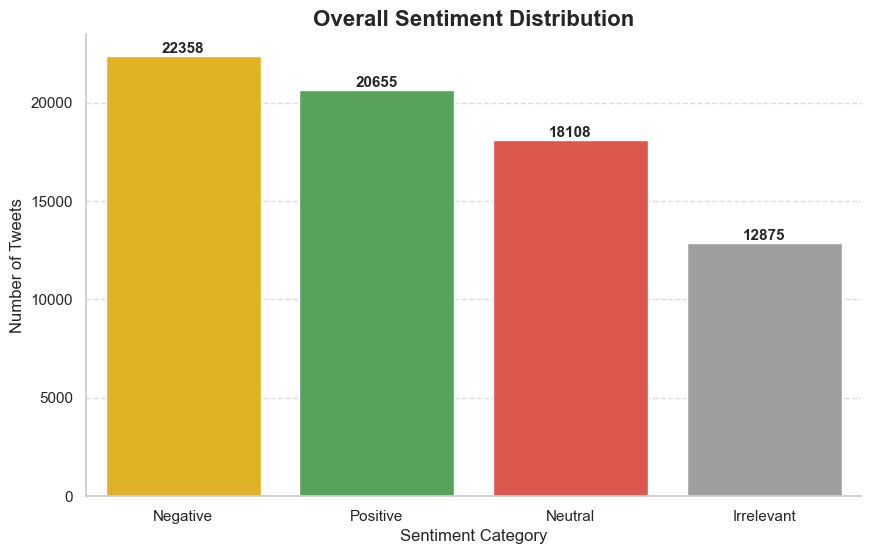

In [54]:
plt.figure(figsize=(10,6))

colors = ["#4CAF50", "#F44336", "#FFC107", "#9E9E9E"]

ax = sns.countplot(
    data=df,
    x="Sentiment",
    hue="Sentiment",  
    order=df["Sentiment"].value_counts().index,
    palette=colors,
    legend=False   
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

plt.title("Overall Sentiment Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Sentiment Category", fontsize=12)
plt.ylabel("Number of Tweets", fontsize=12)

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Insight
This chart shows the overall distribution of sentiments in the dataset. It helps us understand whether users are mostly positive, negative, neutral, or irrelevant in their opinions.

## Sentiment Distribution(Donut Chart)

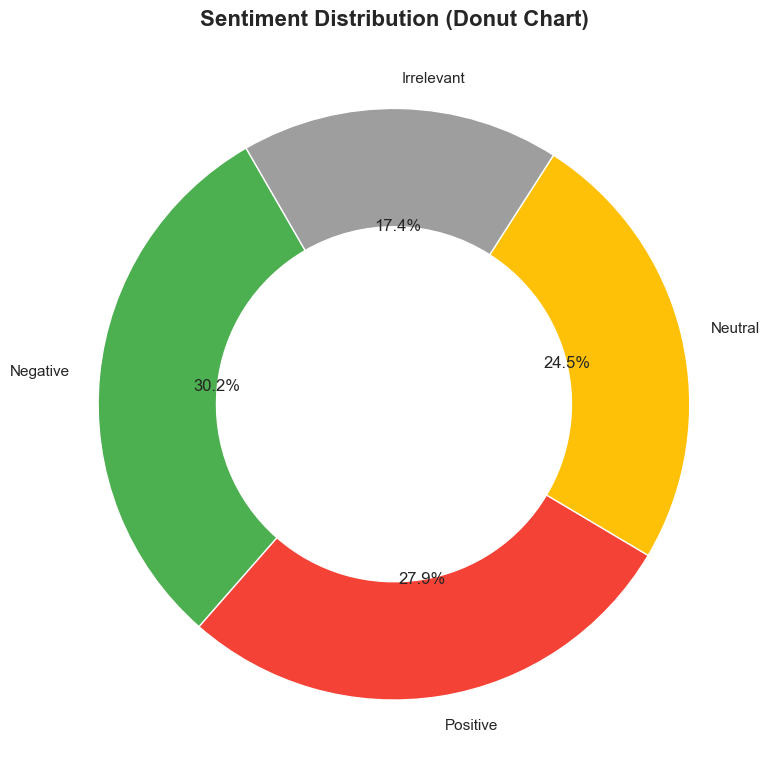

In [55]:
import matplotlib.pyplot as plt
sentiment_counts = df["Sentiment"].value_counts()
colors = ["#4CAF50", "#F44336", "#FFC107", "#9E9E9E"]
plt.figure(figsize=(8,8))
plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=120,
    colors=colors,
    wedgeprops={'width':0.4, 'edgecolor':'white'}  # donut style
)

plt.title("Sentiment Distribution (Donut Chart)", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## Insight
The donut chart shows the percentage share of each sentiment category. This gives a quick understanding of the overall public mood in the dataset.

## Top 10 Most Discussed Entities

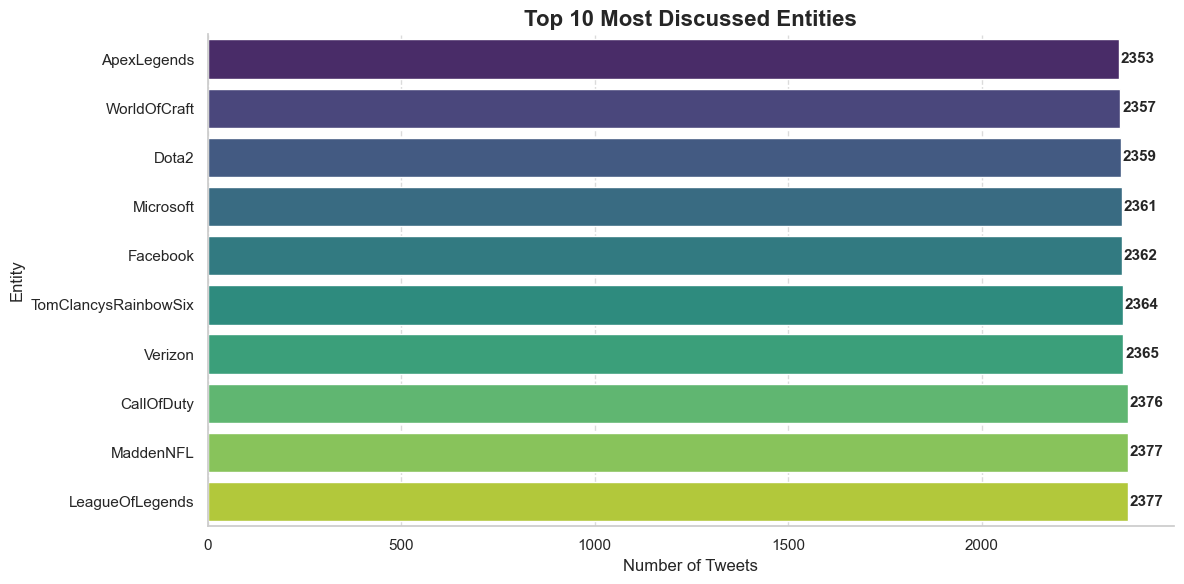

In [56]:
top_entities = df["Entity"].value_counts().head(10).sort_values()

plt.figure(figsize=(12,6))

colors = sns.color_palette("viridis", len(top_entities))

ax = sns.barplot(
    x=top_entities.values,
    y=top_entities.index,
    hue=top_entities.index,   # 👈 ADD THIS
    palette=colors,
    legend=False              # 👈 REMOVE LEGEND
)

# Add value labels
for i, v in enumerate(top_entities.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=11, fontweight='bold')

plt.title("Top 10 Most Discussed Entities", fontsize=16, fontweight='bold')
plt.xlabel("Number of Tweets", fontsize=12)
plt.ylabel("Entity", fontsize=12)

sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Insight
These are the most discussed entities in the dataset. A high number of tweets means users are actively talking about that brand/topic.

## Sentiment Distribution Across Top 10 Entities

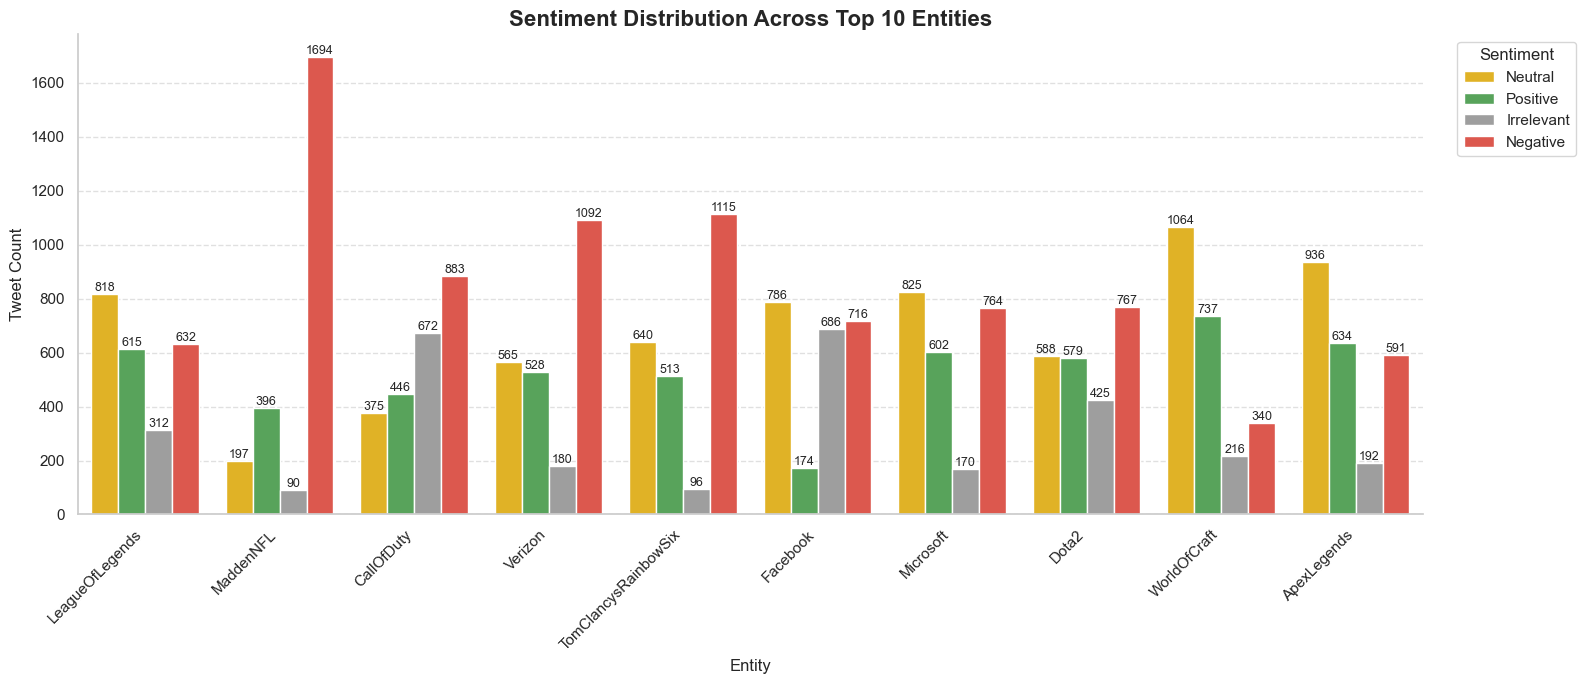

In [57]:
top_10_entities = df["Entity"].value_counts().head(10).index
df_top = df[df["Entity"].isin(top_10_entities)]
plt.figure(figsize=(16,7))
palette = {
    "Positive": "#4CAF50",
    "Negative": "#F44336",
    "Neutral": "#FFC107",
    "Irrelevant": "#9E9E9E"
}
ax = sns.countplot(
    data=df_top,
    x="Entity",
    hue="Sentiment",
    order=top_10_entities,
    palette=palette
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=9
        )

plt.title("Sentiment Distribution Across Top 10 Entities", fontsize=16, fontweight='bold')
plt.xlabel("Entity", fontsize=12)
plt.ylabel("Tweet Count", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Sentiment", bbox_to_anchor=(1.02, 1), loc='upper left')
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Insight
This chart compares sentiment distribution across the top 10 most discussed entities. It helps identify which brands or topics have stronger positive or negative public reactions.

## Top 10 Positive Entities

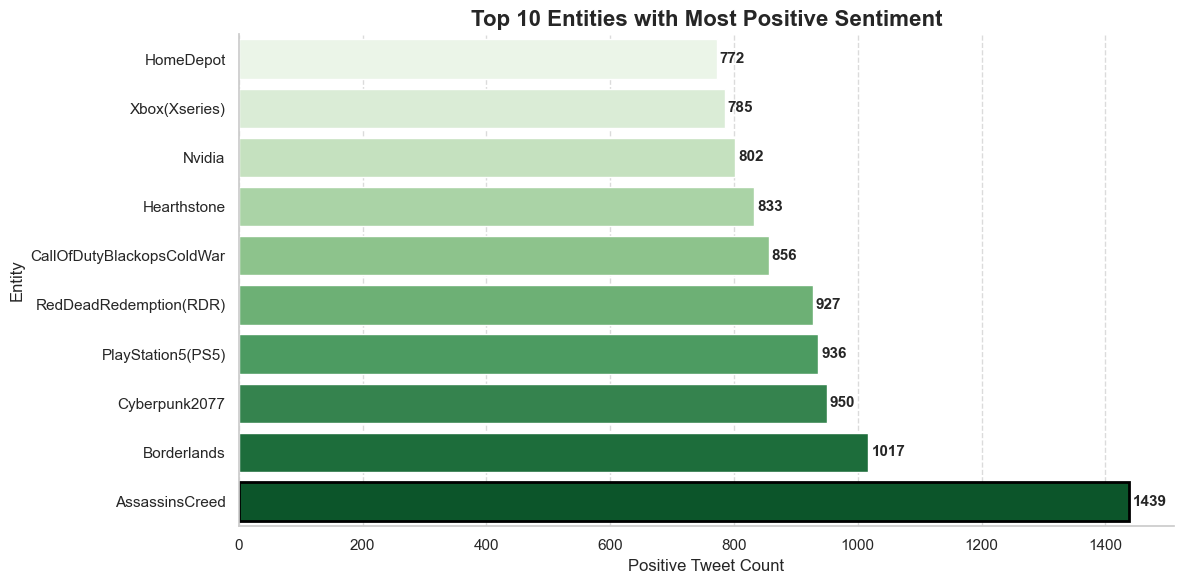

In [58]:
positive_entities = (
    df[df["Sentiment"] == "Positive"]["Entity"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(12,6))

# Smooth gradient palette
colors = sns.color_palette("Greens", len(positive_entities))

ax = sns.barplot(
    x=positive_entities.values,
    y=positive_entities.index,
    hue=positive_entities.index, 
    palette=colors,
    legend=False
)

# Add value labels
for i, v in enumerate(positive_entities.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=11, fontweight='bold')

# Highlight top entity
ax.patches[-1].set_edgecolor("black")
ax.patches[-1].set_linewidth(2)

# Titles & styling
plt.title("Top 10 Entities with Most Positive Sentiment", fontsize=16, fontweight='bold')
plt.xlabel("Positive Tweet Count", fontsize=12)
plt.ylabel("Entity", fontsize=12)

sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Insight
This chart highlights entities receiving the highest number of positive tweets. These brands or topics are viewed more favorably by users.

## Top 10 Negative Entities

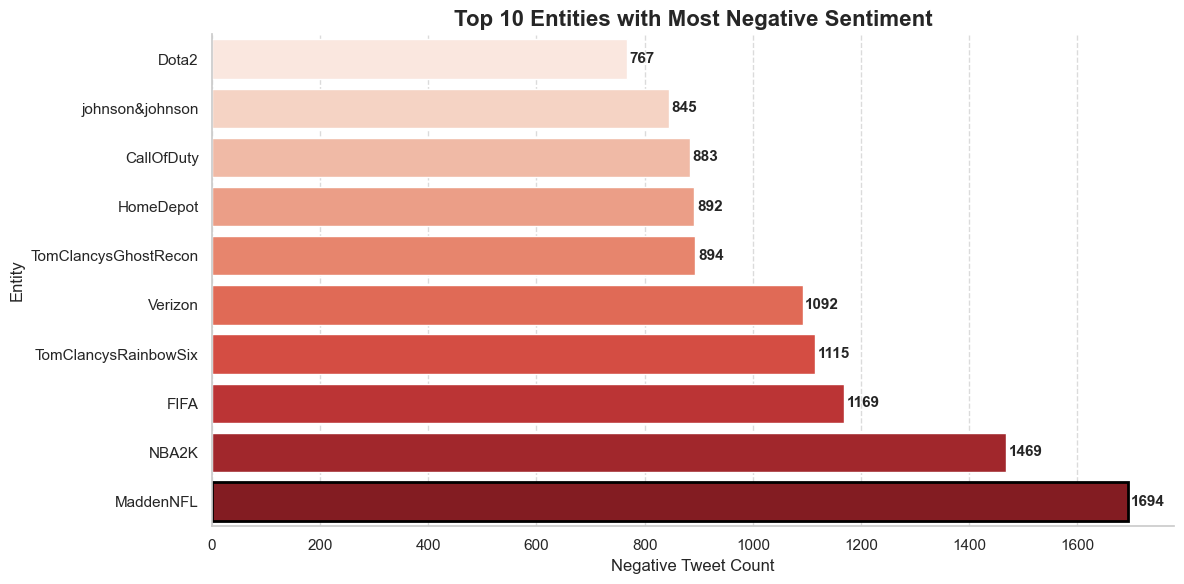

In [59]:
negative_entities = (
    df[df["Sentiment"] == "Negative"]["Entity"]
    .value_counts()
    .head(10)
    .sort_values()
)
plt.figure(figsize=(12,6))
colors = sns.color_palette("Reds", len(negative_entities))

ax = sns.barplot(
    x=negative_entities.values,
    y=negative_entities.index,
    hue=negative_entities.index,
    palette=colors,
    legend=False
)
for i, v in enumerate(negative_entities.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=11, fontweight='bold')
ax.patches[-1].set_edgecolor("black")
ax.patches[-1].set_linewidth(2)
plt.title("Top 10 Entities with Most Negative Sentiment", fontsize=16, fontweight='bold')
plt.xlabel("Negative Tweet Count", fontsize=12)
plt.ylabel("Entity", fontsize=12)

sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Insight
This chart shows entities receiving the highest number of negative tweets. These entities may be facing criticism, dissatisfaction, or negative public perception.

## Tweet Length Analysis

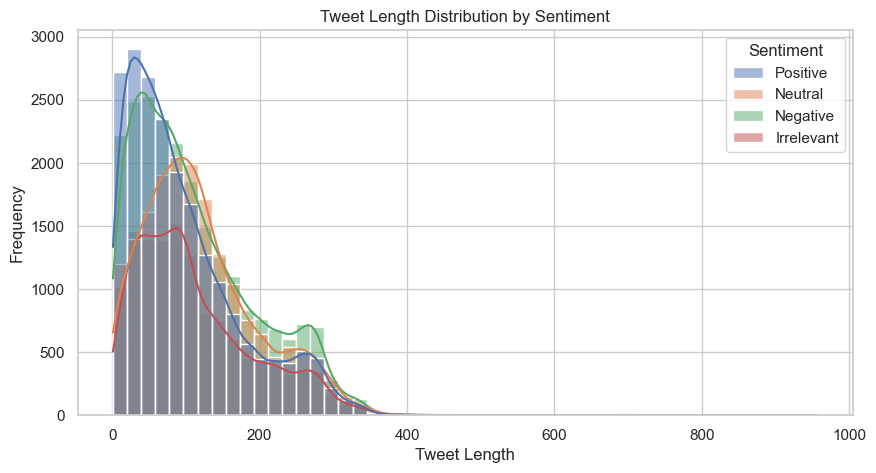

In [60]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x="Tweet_Length", hue="Sentiment", bins=50, kde=True)
plt.title("Tweet Length Distribution by Sentiment")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")
plt.show()

## Insight
This chart shows how tweet length varies across sentiment categories. Longer tweets may indicate detailed opinions or complaints, while shorter tweets may represent quick reactions.

In [61]:
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = text.strip()
    return text

df["Clean_Tweet"] = df["Tweet"].apply(clean_text)

df[["Tweet", "Clean_Tweet"]].head()

,Tweet,Clean_Tweet
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,i am coming to the borders and i will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you all
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands and i will murder y...


In [62]:
!pip install wordcloud

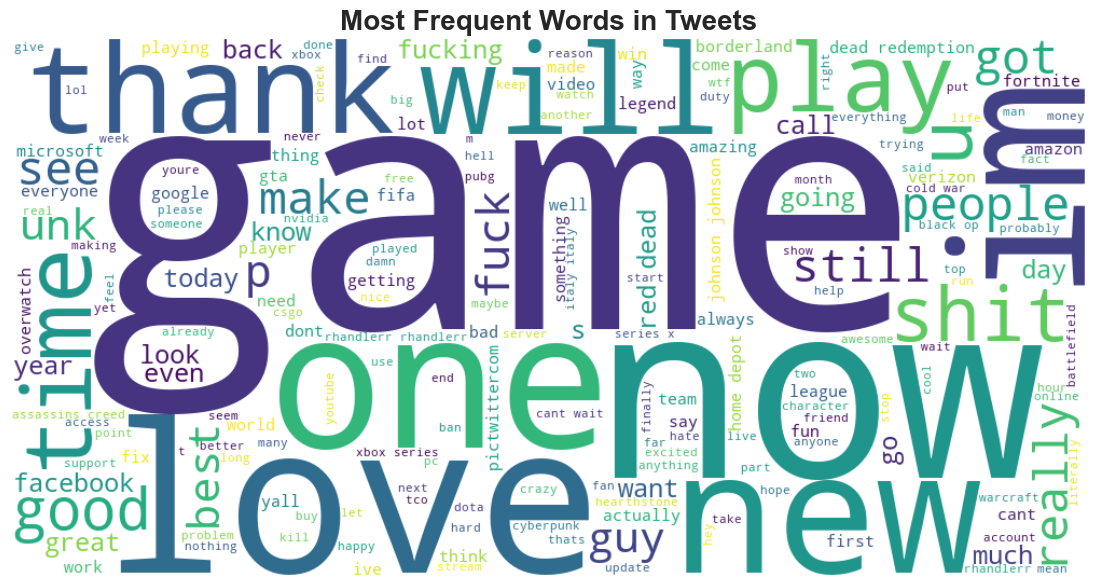

In [63]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["Clean_Tweet"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Tweets", fontsize=20, fontweight='bold')
plt.show()

## Insight
The WordCloud highlights the most frequently used words in tweets. Larger words appear more often and help identify common discussion themes among users.

## Positive vs Negative Ratio Analysis

In [64]:
sentiment_ratio = (
    df.groupby(["Entity", "Sentiment"])
    .size()
    .unstack(fill_value=0)
)

sentiment_ratio["Total"] = sentiment_ratio.sum(axis=1)

sentiment_ratio["Positive_Ratio"] = sentiment_ratio["Positive"] / sentiment_ratio["Total"]
sentiment_ratio["Negative_Ratio"] = sentiment_ratio["Negative"] / sentiment_ratio["Total"]

sentiment_ratio.head()

Sentiment,Irrelevant,Negative,Neutral,Positive,Total,Positive_Ratio,Negative_Ratio
Entity,,,,,,,
Amazon,186,575,1207,308,2276,0.135325,0.252636
ApexLegends,192,591,936,634,2353,0.269443,0.251169
AssassinsCreed,264,375,156,1439,2234,0.644136,0.167860
Battlefield,915,464,351,586,2316,0.253022,0.200345
Borderlands,240,426,597,1017,2280,0.446053,0.186842


## Top Entities by Positive Ratio

In [65]:
top_positive_ratio = sentiment_ratio[sentiment_ratio["Total"] > 100].sort_values(
    by="Positive_Ratio", 
    ascending=False
).head(10)

top_positive_ratio[["Positive_Ratio"]]

Sentiment,Positive_Ratio
Entity,
AssassinsCreed,0.644136
Borderlands,0.446053
Cyberpunk2077,0.419982
RedDeadRedemption(RDR),0.412183
PlayStation5(PS5),0.408555
CallOfDutyBlackopsColdWar,0.365344
Hearthstone,0.364392
Nvidia,0.353148
Xbox(Xseries),0.343846


## Top Entities by Negative Ratio

In [66]:
top_negative_ratio = sentiment_ratio[sentiment_ratio["Total"] > 100].sort_values(
    by="Negative_Ratio", 
    ascending=False
).head(10)

top_negative_ratio[["Negative_Ratio"]]

Sentiment,Negative_Ratio
Entity,
MaddenNFL,0.712663
NBA2K,0.626974
FIFA,0.503012
TomClancysRainbowSix,0.471658
Verizon,0.461734
HomeDepot,0.389180
TomClancysGhostRecon,0.385179
CallOfDuty,0.371633
johnson&johnson,0.363597


## Business Insight
Using sentiment ratio is better than only using tweet count because it shows the percentage of positive or negative sentiment for each entity.

An entity with fewer total tweets may still have a very high negative ratio, which can indicate serious dissatisfaction among users.

## Final Conclusion
In this project, i explored Twitter sentiment data to understand how people feel about different brands and topics. 
After cleaning the dataset and removing missing values, i created additional features like tweet length and word count to get deeper insights.

Through various visualizations, i was able to see how sentiments are distributed, which entities are most discussed, and which ones receive more positive or negative reactions. 
This helped in understanding overall public opinion in a clearer way.

Such analysis can be very useful for companies, as it allows them to track their brand image, identify areas where customers may be dissatisfied, and make better decisions based on real user feedback from social media.
